In [6]:
using CSV
using DataFrames
using Distributions
using Plots
using StatsPlots

┌ Info: Precompiling CSV [336ed68f-0bac-5ca0-87d4-7b16caf5d00b]
└ @ Base loading.jl:1278


LoadError: ArgumentError: Package DataFrames not found in current path:
- Run `import Pkg; Pkg.add("DataFrames")` to install the DataFrames package.


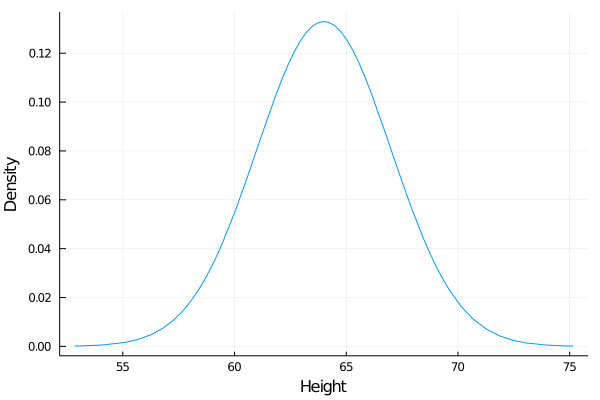

In [3]:
plot(Normal(64, 3), 
     xlabel="Height", 
     ylabel="Density", 
     legend=false)

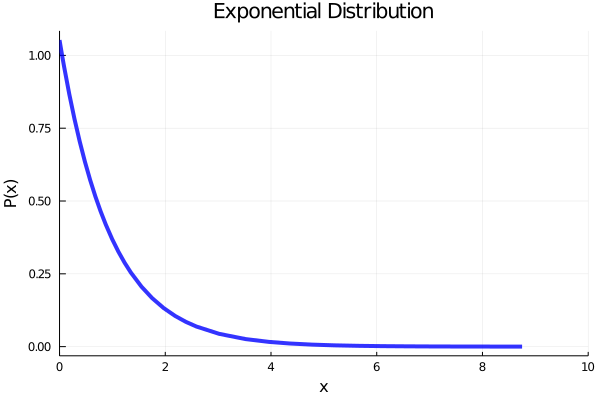

In [4]:
plot(Exponential(0.95), 
     xlabel="x", 
     ylabel="P(x)", 
     lw=4, 
     color="blue", 
     label=false, 
     alpha=0.8, 
     title="Exponential Distribution", 
     xlim=(0, 10))

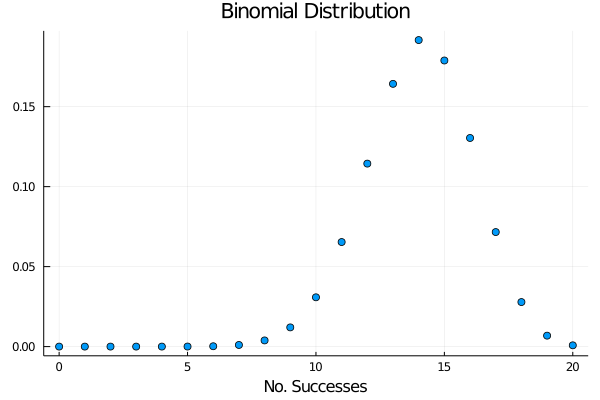

In [7]:
scatter(Binomial(20, 0.7), 
        xlim=300, 
        label=false, 
        title="Binomial Distribution", 
        xlabel="No. Successes")

In [9]:
mutable struct beta_bandit
    p::Float64 # probability of success (win)
    a::Int64   # a param to the beta distribution (successes)
    b::Int64   # b param to the beta distribution (failures)
    N::Int64   # Number of trials
    # init Beta as uniform
    beta_bandit(p=p, a=1, b=1, N=0) = new(p, a, b, N)
end

In [10]:
sample_bandit(bandit::beta_bandit) = rand(Beta(bandit.a, bandit.b))

sample_bandit (generic function with 1 method)

In [11]:
pull_arm(bandit::beta_bandit) = bandit.p > rand()

pull_arm (generic function with 1 method)

In [23]:
function update_bandit(bandit::beta_bandit, result)
    result ? bandit.a += 1 : bandit.b += 1
end

update_bandit (generic function with 1 method)

In [24]:
N_TRIALS = 100
BANDIT_PROBS = Float64[0.3, 0.5, 0.7]

3-element Array{Float64,1}:
 0.3
 0.5
 0.7

In [25]:
function beta_bandit_experiment(bandit_probs, trials)
    bandits = [beta_bandit(p) for p in bandit_probs]
    reward = 0
    for i in 1:trials
        _, mxidx = findmax([sample_bandit(bandit) for bandit in bandits])
        best_bandit = bandits[mxidx]
        exp = pull_arm(best_bandit)
        exp & (reward += 1)
        update_bandit(best_bandit, exp)
    end
    plot()
    for i in 1:length(bandits)
        display(
            plot!(
                Beta(bandits[i].a, bandits[i].b), 
                xlim=(0, 1), 
                lw=2, 
                xlabel="P(success)", 
                ylabel="Density"))
    end
    return reward, current()
end

beta_bandit_experiment (generic function with 1 method)

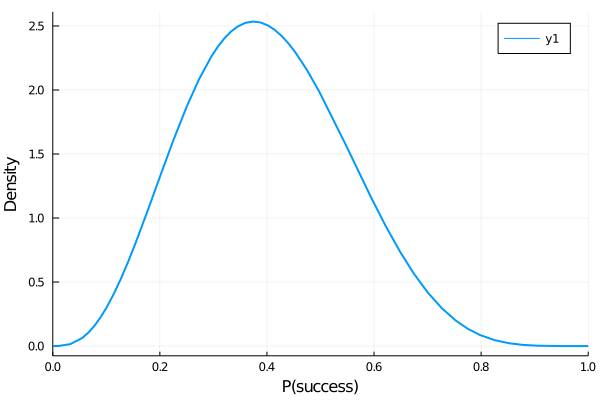

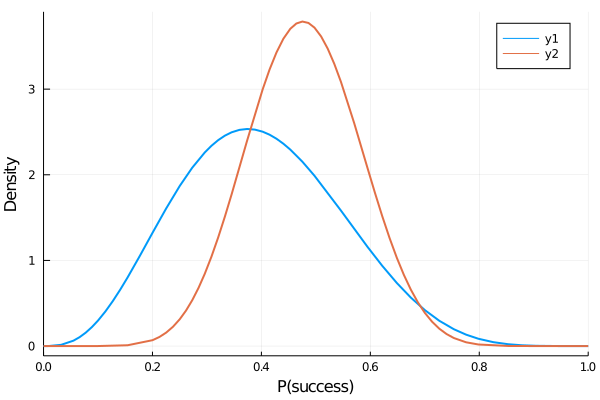

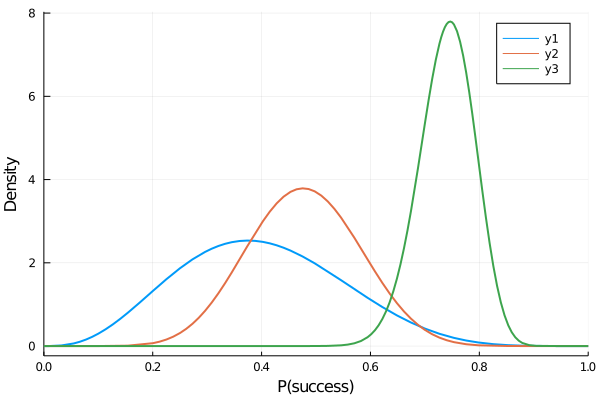

(100, Plot{Plots.GRBackend() n=3})

In [26]:
reward, plt = beta_bandit_experiment(BANDIT_PROBS, N_TRIALS)